# 🤖 Notebook 3 — RobBERT Sentiment Analysis
**Input:** `speeches_features.csv`  **Output:** `speeches_with_sentiment.csv`

**Model used:**
| Task | Model | Why |
|---|---|---|
| Sentiment | `DTAI-KULeuven/robbert-v2-dutch-sentiment` | RobBERT fine-tuned on Dutch sentiment corpora |

**What this notebook does:**  
Runs sentiment on the actual speech transcripts, keeps all original columns from the input CSV,
adds sentiment columns for each speech, and saves the result to Google Drive.

**Chunking:** speeches > 512 tokens are split into overlapping chunks; scores are
averaged across chunks to preserve information from long speeches.


In [1]:
# !pip install transformers torch sentencepiece

In [2]:
import pandas as pd, numpy as np, torch
from transformers import AutoTokenizer, pipeline
import matplotlib.pyplot as plt, matplotlib.ticker as mtick
import seaborn as sns, warnings
warnings.filterwarnings('ignore')
DEVICE = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU' if DEVICE==0 else 'CPU'}  |  PyTorch {torch.__version__}")
plt.rcParams.update({'figure.dpi':130,'axes.spines.top':False,'axes.spines.right':False})
BLUE,RED,GREEN,ORANGE,GREY = '#2B5797','#C0392B','#27AE60','#E67E22','#95A5A6'
df = pd.read_csv('speeches_features.csv', low_memory=False)
texts = df['speech_text_clean'].fillna(df['speech_text']).str[:2000].tolist()
print(f"Loaded {len(texts):,} speeches")


Device: GPU  |  PyTorch 2.10.0+cu128
Loaded 30,149 speeches


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 1. RobBERT Sentiment with Chunking

In [4]:
SENTIMENT_MODEL = "DTAI-KULeuven/robbert-v2-dutch-sentiment"
print(f"Loading: {SENTIMENT_MODEL}  (~500 MB, cached after first run)")
sent_tok  = AutoTokenizer.from_pretrained(SENTIMENT_MODEL)
sent_pipe = pipeline("text-classification", model=SENTIMENT_MODEL, tokenizer=SENTIMENT_MODEL,
                     device=DEVICE, top_k=None, truncation=True, max_length=512)
print("Model loaded ✓")

Loading: DTAI-KULeuven/robbert-v2-dutch-sentiment  (~500 MB, cached after first run)


config.json:   0%|          | 0.00/875 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: DTAI-KULeuven/robbert-v2-dutch-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded ✓


In [5]:
def chunk_text(text, tokenizer, max_tokens=512, stride=64):
    """Split long speech into overlapping token chunks for mean-pooled scoring."""
    tokens = tokenizer.encode(text, add_special_tokens=False, truncation=False)
    if len(tokens) <= max_tokens:
        return [text]
    chunks, step = [], max_tokens - stride
    for start in range(0, len(tokens), step):
        chunks.append(tokenizer.decode(tokens[start:start+max_tokens], skip_special_tokens=True))
        if start + max_tokens >= len(tokens): break
    return chunks

def run_sentiment(texts, pipe, tokenizer, batch_size=32):
    records = []
    for i, text in enumerate(texts):
        chunks = chunk_text(str(text), tokenizer)
        chunk_scores = []
        for j in range(0, len(chunks), batch_size):
            for out in pipe(chunks[j:j+batch_size]):
                scores = {o['label'].lower(): o['score'] for o in out}
                pos = scores.get('positive', scores.get('pos', 0.5))
                neg = scores.get('negative', scores.get('neg', 0.5))
                chunk_scores.append({'pos':pos,'neg':neg})
        avg_pos = np.mean([c['pos'] for c in chunk_scores])
        avg_neg = np.mean([c['neg'] for c in chunk_scores])
        records.append({'sentiment_label':'positive' if avg_pos>=avg_neg else 'negative',
                        'sentiment_pos':round(avg_pos,4),'sentiment_neg':round(avg_neg,4),
                        'sentiment_score':round(avg_pos-avg_neg,4),'n_chunks':len(chunks)})
        if i % 500 == 0: print(f"  Sentiment: {i:,}/{len(texts):,}")
    return pd.DataFrame(records)

print("Running RobBERT sentiment inference (use GPU for speed) ...")
sent_df = run_sentiment(texts, sent_pipe, sent_tok, batch_size=32)
print(f"Done ✓  |  {sent_df['n_chunks'].gt(1).sum():,} speeches were chunked")
print(sent_df['sentiment_label'].value_counts().to_string())

Running RobBERT sentiment inference (use GPU for speed) ...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Sentiment: 0/30,149
  Sentiment: 500/30,149
  Sentiment: 1,000/30,149
  Sentiment: 1,500/30,149
  Sentiment: 2,000/30,149
  Sentiment: 2,500/30,149
  Sentiment: 3,000/30,149
  Sentiment: 3,500/30,149
  Sentiment: 4,000/30,149
  Sentiment: 4,500/30,149
  Sentiment: 5,000/30,149
  Sentiment: 5,500/30,149
  Sentiment: 6,000/30,149
  Sentiment: 6,500/30,149
  Sentiment: 7,000/30,149
  Sentiment: 7,500/30,149
  Sentiment: 8,000/30,149
  Sentiment: 8,500/30,149
  Sentiment: 9,000/30,149
  Sentiment: 9,500/30,149
  Sentiment: 10,000/30,149
  Sentiment: 10,500/30,149
  Sentiment: 11,000/30,149
  Sentiment: 11,500/30,149
  Sentiment: 12,000/30,149
  Sentiment: 12,500/30,149
  Sentiment: 13,000/30,149
  Sentiment: 13,500/30,149
  Sentiment: 14,000/30,149
  Sentiment: 14,500/30,149
  Sentiment: 15,000/30,149
  Sentiment: 15,500/30,149
  Sentiment: 16,000/30,149
  Sentiment: 16,500/30,149
  Sentiment: 17,000/30,149
  Sentiment: 17,500/30,149
  Sentiment: 18,000/30,149
  Sentiment: 18,500/30,149


Token indices sequence length is longer than the specified maximum sequence length for this model (641 > 512). Running this sequence through the model will result in indexing errors


  Sentiment: 28,500/30,149
  Sentiment: 29,000/30,149
  Sentiment: 29,500/30,149
  Sentiment: 30,000/30,149
Done ✓  |  46 speeches were chunked
sentiment_label
positive    20035
negative    10114


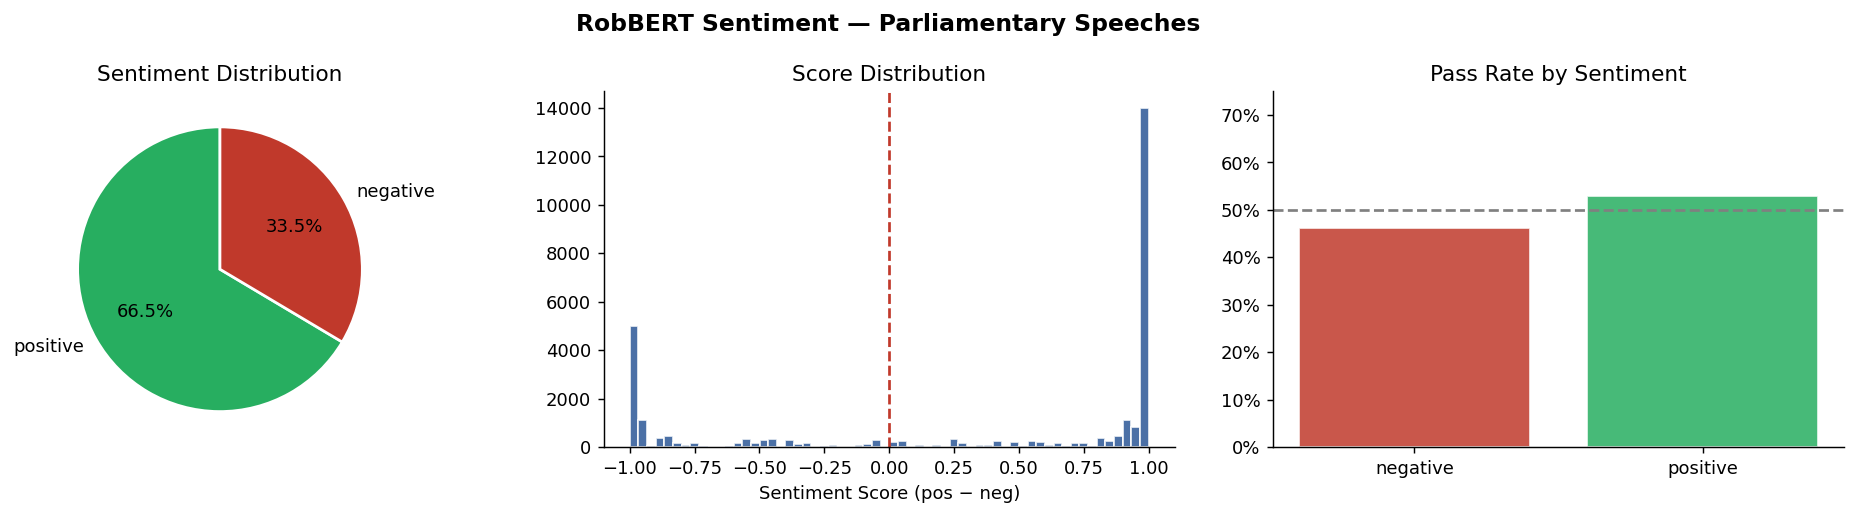

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('RobBERT Sentiment — Parliamentary Speeches', fontsize=13, fontweight='bold')

counts = sent_df['sentiment_label'].value_counts()
axes[0].pie(counts, labels=counts.index,
            colors=[GREEN if l=='positive' else RED for l in counts.index],
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Sentiment Distribution')

axes[1].hist(sent_df['sentiment_score'], bins=60, color=BLUE, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color=RED, linestyle='--')
axes[1].set_xlabel('Sentiment Score (pos − neg)'); axes[1].set_title('Score Distribution')

df_tmp = df.copy()
df_tmp['sentiment_label'] = sent_df['sentiment_label'].values
df_tmp['sentiment_score'] = sent_df['sentiment_score'].values
acc_s = df_tmp.groupby('sentiment_label')['label'].mean()*100
axes[2].bar(acc_s.index, acc_s.values,
            color=[GREEN if l=='positive' else RED for l in acc_s.index],
            edgecolor='white', alpha=0.85)
axes[2].axhline(50, color='grey', linestyle='--')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[2].set_title('Pass Rate by Sentiment'); axes[2].set_ylim(0,75)
plt.tight_layout(); plt.show()

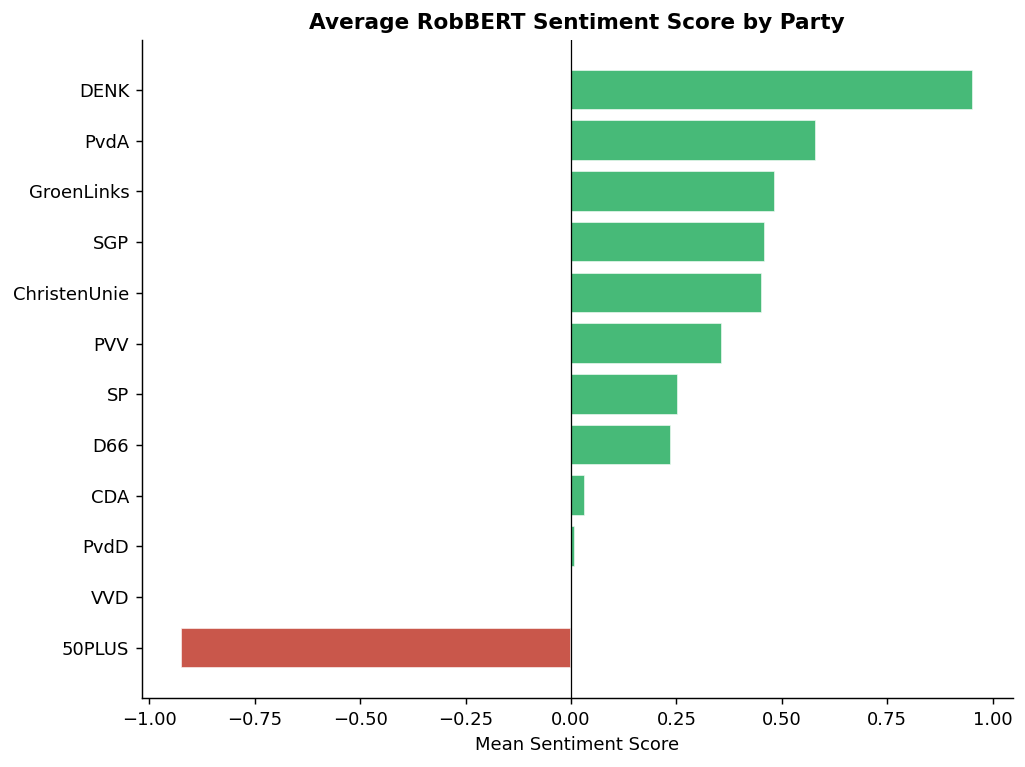

In [7]:
# Sentiment by party
df['sentiment_score'] = sent_df['sentiment_score'].values
df['sentiment_label'] = sent_df['sentiment_label'].values
top_p = df['speaker_party'].value_counts().head(12).index
ps = df[df['speaker_party'].isin(top_p)].groupby('speaker_party')['sentiment_score'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8,6))
ax.barh(ps.index, ps.values, color=[GREEN if v>=0 else RED for v in ps.values], edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', lw=0.7)
ax.set_title('Average RobBERT Sentiment Score by Party', fontweight='bold')
ax.set_xlabel('Mean Sentiment Score')
plt.tight_layout(); plt.show()

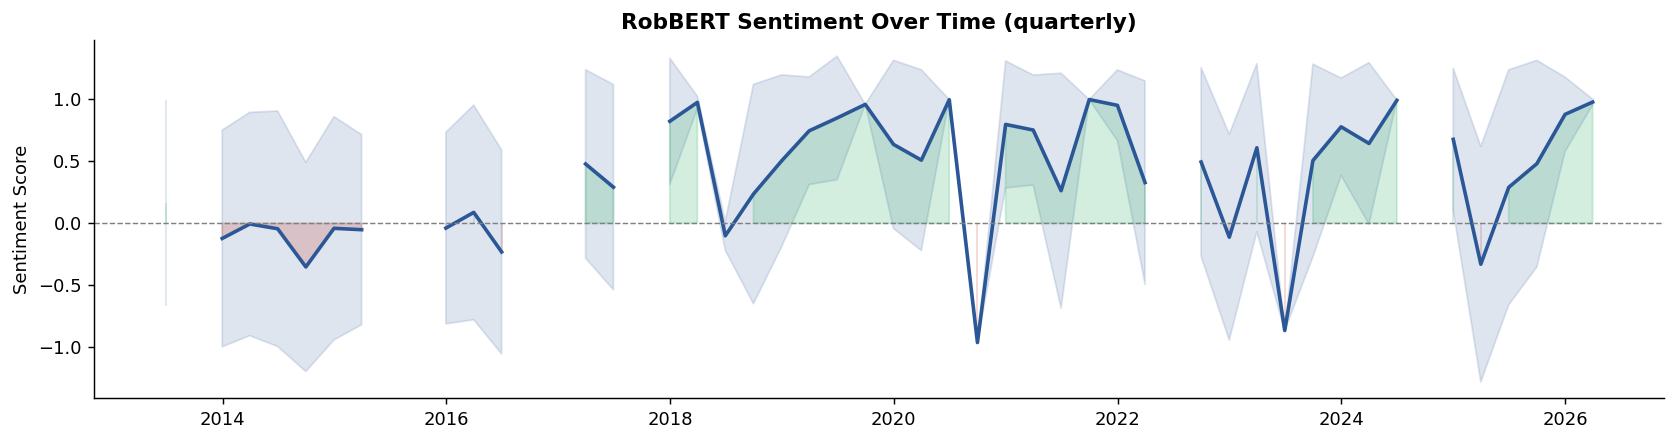

In [8]:
# Sentiment over time (quarterly)
df['vergadering_datum'] = pd.to_datetime(df['vergadering_datum'], errors='coerce')
df_ts = df.dropna(subset=['vergadering_datum','sentiment_score']).set_index('vergadering_datum')
q_mean = df_ts['sentiment_score'].resample('QE').mean()
q_std  = df_ts['sentiment_score'].resample('QE').std()

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(q_mean.index, q_mean.values, color=BLUE, lw=2)
ax.fill_between(q_mean.index, q_mean-q_std, q_mean+q_std, alpha=0.15, color=BLUE)
ax.fill_between(q_mean.index, q_mean.values, 0, where=(q_mean.values>0), alpha=0.2, color=GREEN)
ax.fill_between(q_mean.index, q_mean.values, 0, where=(q_mean.values<=0), alpha=0.2, color=RED)
ax.axhline(0, color='grey', lw=0.8, linestyle='--')
ax.set_title('RobBERT Sentiment Over Time (quarterly)', fontweight='bold')
ax.set_ylabel('Sentiment Score')
plt.tight_layout(); plt.show()

## 2. Save output CSV


In [9]:
# Add sentiment columns back to the original dataframe and save the full CSV safely
df['sentiment_label'] = sent_df['sentiment_label'].values
df['sentiment_pos'] = sent_df['sentiment_pos'].values
df['sentiment_neg'] = sent_df['sentiment_neg'].values
df['sentiment_score'] = sent_df['sentiment_score'].values
df['n_chunks'] = sent_df['n_chunks'].values

output_path = '/content/drive/MyDrive/speeches_with_sentiment.csv'
df.to_csv(output_path, index=False)
print(f'Saved {len(df):,} rows to {output_path}')


Saved 30,149 rows to /content/drive/MyDrive/speeches_with_sentiment.csv
